In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from scipy.ndimage import uniform_filter
import shutil

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
fly_num = '208'
fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}'
STA_name = 'stepsize_10_STA.h5'
STA_path = os.path.join(fly_path, 'STA', STA_name)
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'


In [4]:
fly_list=['208', '209', '210', '217', '218', '226', '227', '228', '233', '234', '239', '240', '241', '242', '249', '250']
step_size=100
for fly in fly_list:
    fly_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}'
    files = os.listdir(os.path.join(fly_path, 'STA'))
    file = f"stepsize_{step_size}_STA.h5"
    if file in files:
        source = os.path.join(fly_path, 'STA', file)
        new_file = f"{fly}_{file}"
        destination = os.path.join(later_dir, new_file)
        if os.path.exists(destination)==False: 
            dest = shutil.copyfile(source, destination)
        print("Destination path:", destination)
    
    else:
        print("Not there yet!")
    

Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/208_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/209_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/210_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/217_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/218_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/226_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/227_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/228_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/233_stepsize_100_STA.h5
Destination path: /oak/stanford/groups/trc/data/Ilana/2P/data/la

In [6]:
%%time
total_STA=[]
count = len(fly_list)
for fly in fly_list:
    file_name = f"{fly}_stepsize_{step_size}_STA.h5"
    STA_path = os.path.join(later_dir,file_name)
    if os.path.exists(STA_path):
        with h5py.File(STA_path, 'r') as hf:
                brain = hf['data'][:]
                dimsb = np.shape(brain)
                print(f"Brain shape is {dimsb}")
                if len(total_STA)!=0:
                    total_STA+=brain
                else:
                    total_STA=brain
    else:
        count-=1
print(count)
total_STA_temp=total_STA/count
STA=np.asarray(total_STA_temp)

Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
Brain shape is (24, 314, 146, 91)
16
CPU times: user 520 ms, sys: 2.29 s, total: 2.81 s
Wall time: 4.98 s


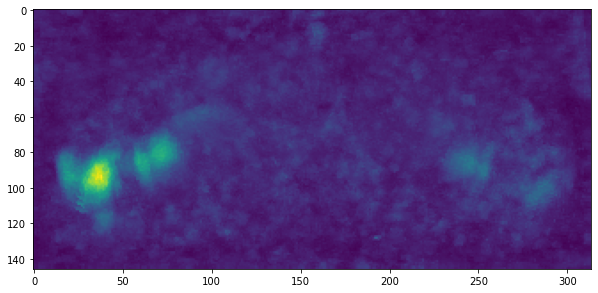

In [8]:
plt.figure(figsize=(10,10))
plt.imshow(np.max(STA[13][:,:,:], axis=-1).T)

In [10]:
total_path=os.path.join(later_dir,f'total_stepsize_{step_size}_STA.npy')
np.save(total_path,STA)

In [11]:
atlas = brainsss.load_roi_atlas()

In [12]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [15]:
np.shape(STA)

(24, 314, 146, 91)

In [23]:
%%time
STA=STA ##### CHANGE THIS
explosions = []
for tp in range(np.shape(STA)[0]):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = STA[tp][:,:,::-1]
    vmax = 0.003 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap='seismic', diverging=True)#'hot')
    explosions.append(explosion_map)

CPU times: user 17.6 s, sys: 23 ms, total: 17.6 s
Wall time: 17.6 s


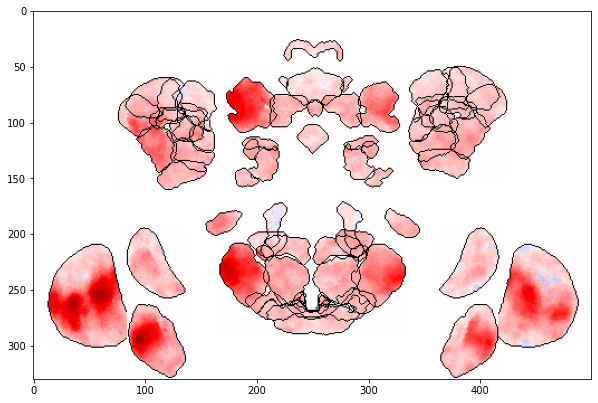

In [24]:
plt.figure(figsize=(10,10))
plt.imshow(explosions[14][170:,:])

In [25]:
movie_dir = os.path.join(later_dir, 'movies')
if os.path.exists(movie_dir)==False:
    os.mkdir(movie_dir)
print(movie_dir)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/movies


In [26]:
save_dir = os.path.join(movie_dir,'dff_total')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/movies/dff_total


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


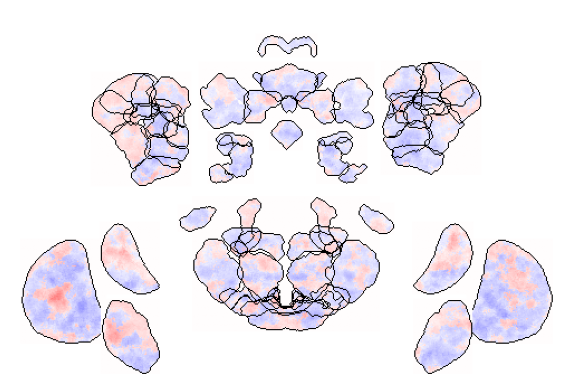

In [27]:
plt.figure(figsize=(10,10))
for i in range(np.shape(STA)[0]):
    print(i)
    plt.imshow(explosions[i][170:,:]) #this was made with cmap=hot
    plt.axis('off')
    fname = os.path.join(save_dir, '{0:05d}.png'.format(i))
    plt.savefig(fname,dpi=300,bbox_inches='tight')